# Deliverable 1

### Task 1

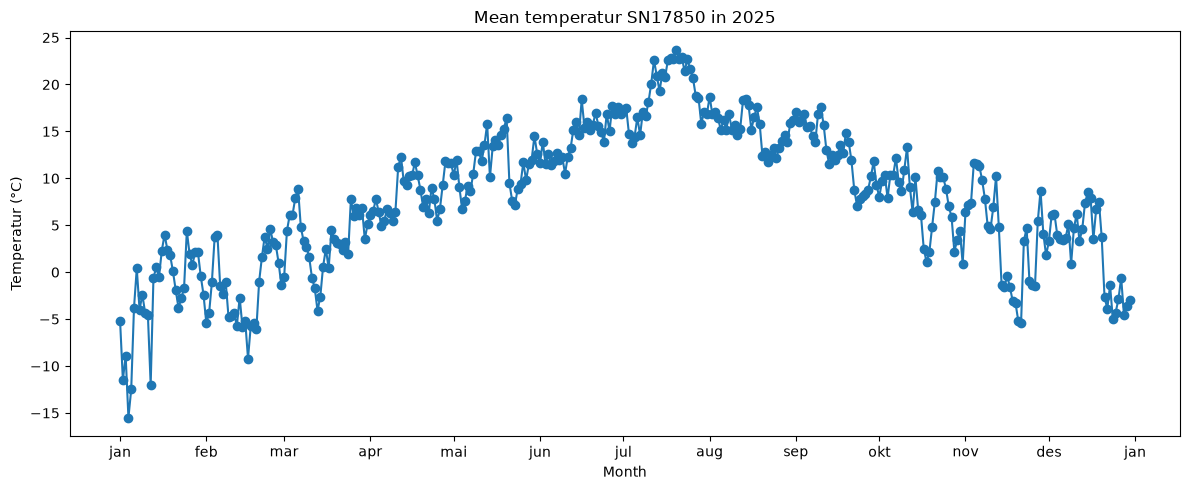

Summary for 2025:

Lowest temperatur: -15.5 °C, measured 2025-01-04
Max temperatur: 23.7 °C, measured 2025-07-20
Mean: 7.9 °C
Median: 8.4 °C


In [4]:
import locale
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import requests
from numpy import mean, median


def load_frost_key(path="../key_frost.py"):
    """Load API client ID from lokal file."""
    sys.path.append("..")
    with open(path, "r", encoding="utf-8") as file:
        return file.read().strip()


def get_frost_data_2025(client_id):
    """Connctin to frost server and get the mean temperatur for 2025."""
    endpoint = "https://frost.met.no/observations/v0.jsonld"
    parameters = {
        "sources": "SN17850",
        "elements": "mean(air_temperature P1D)",
        "referencetime": "2025-01-01/2025-12-31",
    }

    response = requests.get(
        endpoint,
        params=parameters,
        auth=(client_id, "")
    )
    response.raise_for_status()
    return response.json()["data"]


def get_the_rigth_format(data):
    """Change dates and temperatures from Frost API response."""
    dates = []
    temps = []

    for entry in data:
        date = entry["referenceTime"][:10]  # YYYY-MM-DD
        temp = entry["observations"][0]["value"]
        dates.append(date)
        temps.append(temp)

    df = pd.DataFrame({
        "Dato": pd.to_datetime(dates),
        "Temperatur": temps
    })
    df["Dag"] = df["Dato"].dt.dayofyear
    return df


def summary(df):
    """Creating a summary for mean, median, min andn max temperatur for 2025"""
    min_temp = df["Temperatur"].min()
    max_temp = df["Temperatur"].max()
    mean_temp = mean(df["Temperatur"])
    median_temp = median(df["Temperatur"])

    min_date = df.loc[df["Temperatur"].idxmin(), "Dato"].date()
    
    max_date = df.loc[df["Temperatur"].idxmax(), "Dato"].date()
    print("Summary for 2025:\n")
    print(
        f"Lowest temperatur: {min_temp} °C, measured {min_date}\n"
        f"Max temperatur: {max_temp} °C, measured {max_date}"
    )
    print(f"Mean: {mean(mean_temp):.1f} °C")
    print(f"Median: {median(median_temp):.1f} °C")



def plot_temperature(df):
    """Plot temperature series with Norwegian month labels."""
    plt.figure(figsize=(12, 5))
    plt.plot(df["Dato"], df["Temperatur"], marker="o")

    locale.setlocale(locale.LC_TIME, "nb_NO.UTF-8")

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    plt.xticks(rotation=0)
    plt.xlabel("Month")
    plt.ylabel("Temperatur (°C)")
    plt.title("Mean temperatur SN17850 in 2025")
    plt.tight_layout()
    plt.show()


def main():
    client_id = load_frost_key()
    data = get_frost_data_2025(client_id)
    df = get_the_rigth_format(data)
    plot_temperature(df)
    summary(df)

if __name__ == "__main__":
    main()


### Task 2

### Task 3

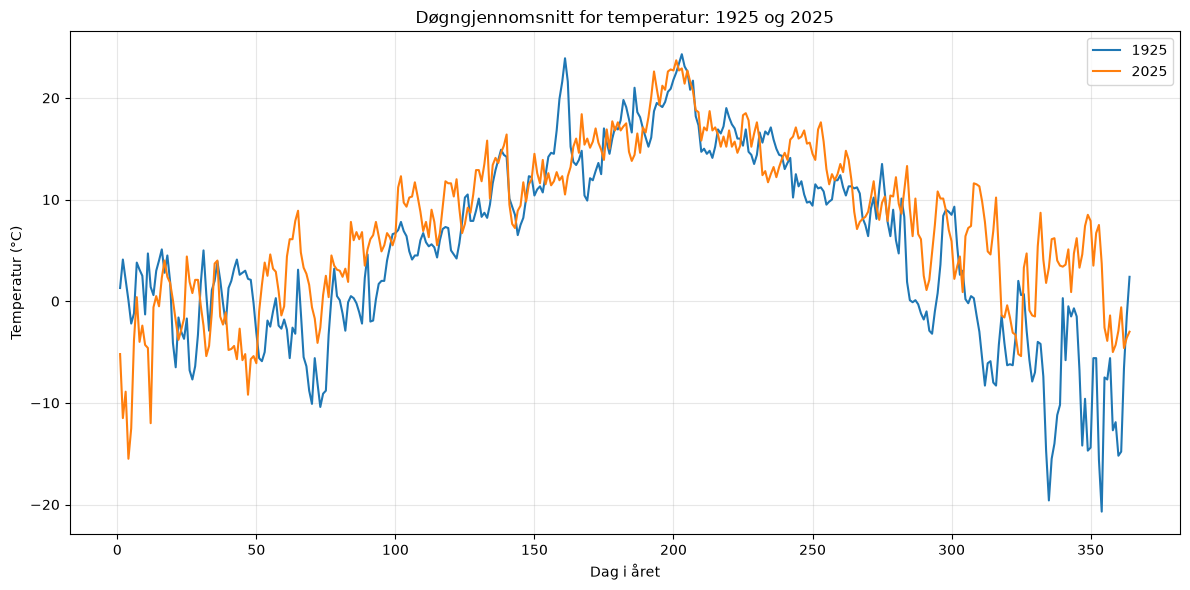


Summary for 1925:
Lowest temperature: -20.7 °C, measured 1925-12-20
Highest temperature: 24.3 °C, measured 1925-07-22
Mean: 5.3 °C
Median: 5.3 °C

Summary for 2025:
Lowest temperature: -15.5 °C, measured 2025-01-04
Highest temperature: 23.7 °C, measured 2025-07-20
Mean: 7.9 °C
Median: 8.4 °C


In [13]:
def get_frost_data_1925(client_id):
    """Connect to Frost API and get mean daily temperature for 1925."""
    endpoint = "https://frost.met.no/observations/v0.jsonld"
    parameters = {
        "sources": "SN17850",
        "elements": "mean(air_temperature P1D)",
        "referencetime": "1925-01-01/1925-12-31",
    }

    response = requests.get(endpoint, params=parameters, auth=(client_id, ""))
    response.raise_for_status()
    return response.json()["data"]


def get_the_right_format(data):
    """Extract dates and temperatures, convert to DataFrame with day-of-year."""
    dates = []
    temps = []

    for entry in data:
        date = entry["referenceTime"][:10]
        temp = entry["observations"][0]["value"]
        dates.append(date)
        temps.append(temp)

    df = pd.DataFrame({
        "Dato": pd.to_datetime(dates),
        "Temperatur": temps
    })
    df["Dag"] = df["Dato"].dt.dayofyear
    return df


def main():
    client_id = load_frost_key()

    data_1925 = get_frost_data_1925(client_id)
    data_2025 = get_frost_data_2025(client_id)

    df_1925 = get_the_right_format(data_1925)
    df_2025 = get_the_right_format(data_2025)

    plot_temperature(df_1925, df_2025)
    summary(df_1925, 1925)
    summary(df_2025, 2025)


if __name__ == "__main__":
    main()


### Task 4

### Task 5